<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/ConjointAnalysis/Conjoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving bbq_summer.csv to bbq_summer (1).csv
Dataset Preview:


,bundleID,starter,maindishI,maindishII,side,dessert,avg_rating
0,1,Fried Chicken Tenders,BBQ Brisket,Sausage,Mac and Cheese,Blondie Brownie,6.04
1,2,Fried Chicken Tenders,BBQ Brisket,Sausage,Mac and Cheese,Apple Pie a la Mode,9.29
2,3,Fried Chicken Tenders,BBQ Brisket,Sausage,Potato Salad,Blondie Brownie,6.20
3,4,Fried Chicken Tenders,BBQ Brisket,Sausage,Potato Salad,Apple Pie a la Mode,8.84
4,5,Fried Chicken Tenders,BBQ Brisket,Sausage,French Fry Platter,Blondie Brownie,8.24



Missing Values:
bundleID      0
starter       0
maindishI     0
maindishII    0
side          0
dessert       0
avg_rating    0
dtype: int64

Model RMSE: 1.8203256215285635

Feature Importance:


,Feature,Importance
2,starter_Jumbo Shrimp Cocktail,0.087987
5,maindishI_BBQ Chicken,0.083777
9,maindishII_Lobster Roll,0.082685
14,side_Potato Salad,0.067212
4,maindishI_BBQ Brisket,0.067147
12,side_French Fry Platter,0.061273
13,side_Mac and Cheese,0.060438
11,maindishII_Steak Sampler,0.056851
10,maindishII_Sausage,0.055851
15,dessert_Apple Pie a la Mode,0.053619


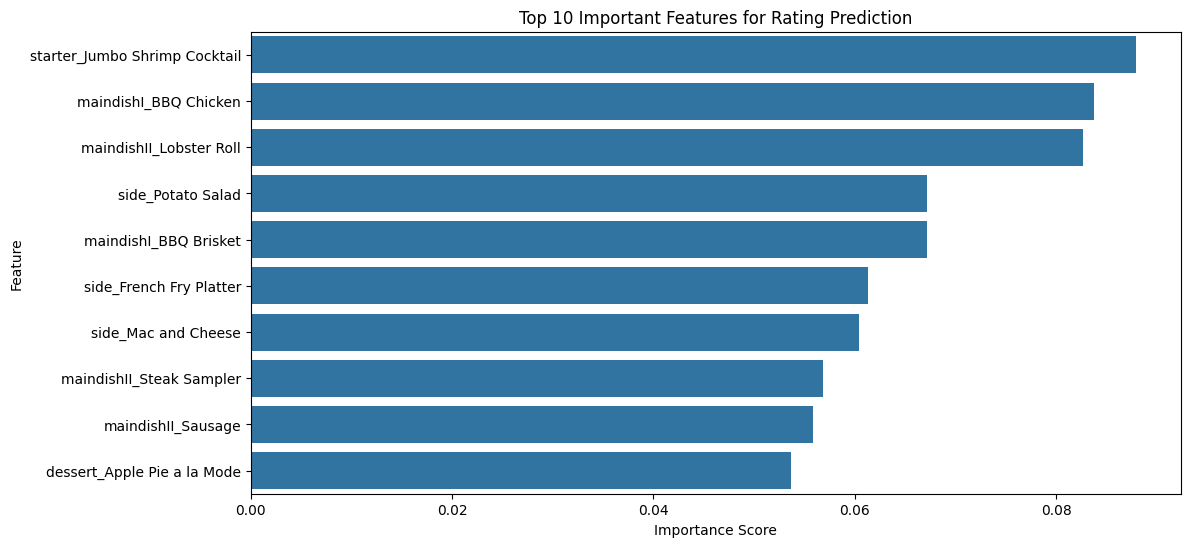


Best Menu Combination:


,starter,maindishI,maindishII,side,dessert,predicted_rating
223,Sticky Chicken Tenders,Pulled Pork,Lobster Roll,Mac and Cheese,Apple Pie a la Mode,9.60176


In [32]:
# Install required libraries
!pip install pandas scikit-learn matplotlib seaborn

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Upload file from local machine
from google.colab import files
uploaded = files.upload()

# Load dataset (Replace 'your_file.csv' with the uploaded filename)
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Display the first few rows
print("Dataset Preview:")
display(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop missing values if any
df.dropna(inplace=True)

# Define categorical columns for encoding
categorical_cols = ['starter', 'maindishI', 'maindishII', 'side', 'dessert']

# OneHot Encoding for categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)  # Fixed sparse issue
encoded_features = encoder.fit_transform(df[categorical_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_cols))

# Combine encoded features with avg_rating
df_encoded = pd.concat([encoded_df, df[['avg_rating']]], axis=1)

# Split data into training and testing sets
X = df_encoded.drop(columns=['avg_rating'])
y = df_encoded['avg_rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nModel RMSE:", rmse)

# Feature Importance Analysis
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display feature importance
print("\nFeature Importance:")
display(feature_importance.head(10))

# Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance['Importance'][:10], y=feature_importance['Feature'][:10])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Important Features for Rating Prediction")
plt.show()

# Finding the best menu combination
starters = df['starter'].unique()
maindishI = df['maindishI'].unique()
maindishII = df['maindishII'].unique()
sides = df['side'].unique()
desserts = df['dessert'].unique()

# Creating all possible menu combinations
menu_combinations = list(product(starters, maindishI, maindishII, sides, desserts))
menu_df = pd.DataFrame(menu_combinations, columns=['starter', 'maindishI', 'maindishII', 'side', 'dessert'])

# Encoding the menu combinations
encoded_menu_features = encoder.transform(menu_df)
encoded_menu_df = pd.DataFrame(encoded_menu_features, columns=encoder.get_feature_names_out(categorical_cols))

# Predict ratings for all combinations
menu_df['predicted_rating'] = model.predict(encoded_menu_df)

# Find the best combination
best_combination = menu_df.loc[menu_df['predicted_rating'].idxmax()]

print("\nBest Menu Combination:")
display(pd.DataFrame(best_combination).T)